In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\anant\OneDrive\Desktop\train_u6lujuX_CVtuZ9i (1).csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])   # categorical
    else:
        df[col] = df[col].fillna(df[col].median())    # numerical


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [8]:
#here we need to use point Biserial correlation because here the target is catogorical(binary)and independent is numerical

In [9]:
from scipy.stats import pointbiserialr
import pandas as pd

binary_col = 'Loan_Status'   # your binary target column (0/1)

# Select only numeric columns except target
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop(binary_col)

results = {}

for col in numeric_cols:
    corr, p_value = pointbiserialr(df[binary_col], df[col])
    results[col] = {'Correlation': corr, 'p-value': p_value}

# Convert to DataFrame for better view
result_df = pd.DataFrame(results).T

print(result_df)


                   Correlation       p-value
Loan_ID               0.011773  7.709371e-01
Gender                0.017987  6.564498e-01
Married               0.091478  2.339836e-02
Dependents            0.010118  8.024165e-01
Education            -0.085884  3.336068e-02
Self_Employed        -0.003700  9.270900e-01
ApplicantIncome      -0.004710  9.072878e-01
CoapplicantIncome    -0.059187  1.429483e-01
LoanAmount           -0.033214  4.113237e-01
Loan_Amount_Term     -0.022549  5.770668e-01
Credit_History        0.540556  7.019682e-48
Property_Area         0.032112  4.270284e-01


In [10]:
from sklearn.model_selection import train_test_split

X = df[['Married', 'Education', 'Self_Employed','Credit_History']]
y = df['Loan_Status']



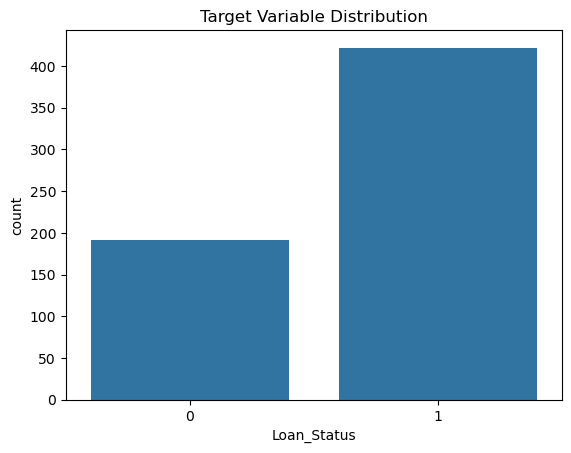

In [11]:
#checking data imbalance
sns.countplot(x='Loan_Status', data=df)
plt.title("Target Variable Distribution")
plt.show()

In [12]:
#huge data imbalance 

In [13]:
# we can use random over sampling

In [17]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from collections import Counter

In [18]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before Oversampling:", Counter(y_train))

# Apply Random Oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print("After Oversampling :", Counter(y_resampled))

Before Oversampling: Counter({1: 337, 0: 154})
After Oversampling : Counter({1: 337, 0: 337})


In [21]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [52]:
# Base learner for AdaBoost
base_tree = DecisionTreeClassifier(max_depth=1)


In [53]:
# AdaBoost model
ada = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=50,
    learning_rate=1.0
)

In [54]:
ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1))

In [55]:
pred = ada.predict(X_test)

In [56]:
pred

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0])

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [58]:
# Confusion Matrix
cm = confusion_matrix(y_test,pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[21 17]
 [ 1 84]]


In [59]:

# Classification report (optional)
print("\nClassification Report:\n")
print(classification_report(y_test,pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [60]:
from sklearn.metrics import accuracy_score

In [61]:
accuracy = accuracy_score(y_test,pred)
print("Accuracy:", accuracy)

Accuracy: 0.8536585365853658


In [62]:
# we got an accuracy of 0.85 but still we need to increase the accuraccy of the mode we need to get the optimum parameter
#so we need to use hyper parameter tuning(grid search cv)

In [63]:
from sklearn.model_selection import GridSearchCV

In [78]:
# Parameter grid
param_grid = {
    "estimator__max_depth": [1, 2, 3],
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 1]
}

In [79]:
# Grid search
grid = GridSearchCV(ada, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1)),
             param_grid={'estimator__max_depth': [1, 2, 3],
                         'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [80]:
# Fit
grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1)),
             param_grid={'estimator__max_depth': [1, 2, 3],
                         'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [81]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'estimator__max_depth': 1, 'learning_rate': 0.01, 'n_estimators': 50}
Best Score: 0.7983714698000413


In [85]:
#the model accuracy decreased

In [90]:
#we cannot use logistic regression in ada boost because logistic regression doesnot support weights


In [92]:
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV


In [93]:
# Base estimator behaving as logistic regression
log_reg_boost = SGDClassifier(loss='log_loss', max_iter=1000)


In [94]:
ada = AdaBoostClassifier(estimator=log_reg_boost)

param_grid = {
    "estimator__alpha": [0.0001, 0.001, 0.01],
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 1]
}

grid = GridSearchCV(ada, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'estimator__alpha': 0.0001, 'learning_rate': 0.01, 'n_estimators': 50}
Best Score: 0.7983714698000413


In [95]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Base estimator
lin_reg = LinearRegression()

# AdaBoost Regressor
ada = AdaBoostRegressor(
    estimator=lin_reg,
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# Train
ada.fit(X_train, y_train)

# Predict
y_pred = ada.predict(X_test)

# Metrics
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


MSE: 0.1628588467751251
R² Score: 0.2837524730055616


by using decision tree in ada boost we get an accuracy of 0.85 and later by appling grid search cv with both logistic and linear the model accuracy reduces to 0.79